In [2]:
"""
LSTM 股票价格预测 —— 完整实现
数据：模拟 2000 条收盘价序列（也可替换为真实 CSV）
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']

# ──────────────────────────────────────────────
# 0. 超参数（集中管理）
# ──────────────────────────────────────────────
SEQ_LEN    = 30       # 用过去 30 天预测第 31 天
HIDDEN_DIM = 64       # LSTM 隐藏层维度
NUM_LAYERS = 2        # LSTM 层数
DROPOUT    = 0.2      # Dropout（num_layers > 1 时生效）
BATCH_SIZE = 32
LR         = 1e-3
EPOCHS     = 80
TRAIN_RATIO= 0.8
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
def generate_stock_prices(n: int = 2000, seed: int = 42) -> np.ndarray:
    """用几何布朗运动 + 周期性噪声模拟股价"""
    np.random.seed(seed)
    mu, sigma, dt = 0.0002, 0.01, 1
    prices = [100.0]
    for _ in range(n - 1):
        shock = np.random.normal(mu, sigma)
        # 加入轻微周期分量，让序列更有规律可学
        cycle = 0.005 * np.sin(2 * np.pi * len(prices) / 60)
        prices.append(prices[-1] * np.exp(shock + cycle))
    return np.array(prices, dtype=np.float32)


prices = generate_stock_prices(2000)
print(f"Price series shape: {prices.shape}, range: [{prices.min():.2f}, {prices.max():.2f}]")

Price series shape: (2000,), range: [90.08, 406.83]


In [4]:
price_min = prices.min()
price_max = prices.max()

def normalize(x):
    return (x - price_min) / (price_max - price_min)

def denormalize(x):
    return x * (price_max - price_min) + price_min

prices_norm = normalize(prices)

In [5]:
class StockDataset(Dataset):
    def __init__(self, series: np.ndarray, seq_len: int):
        self.X, self.y = [], []
        for i in range(len(series) - seq_len):
            self.X.append(series[i : i + seq_len])
            self.y.append(series[i + seq_len])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)  # (N, T, 1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32).unsqueeze(-1)  # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


n_total  = len(prices_norm) - SEQ_LEN
n_train  = int(n_total * TRAIN_RATIO)

train_ds = StockDataset(prices_norm[:n_train + SEQ_LEN], SEQ_LEN)
test_ds  = StockDataset(prices_norm[n_train:],            SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")

Train samples: 1576, Test samples: 394


In [6]:
class LSTMPredictor(nn.Module):
    """
    输入  (batch, seq_len, input_size=1)
    输出  (batch, 1)  —— 预测下一个价格
    """
    def __init__(self, input_size=1, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, T, 1)
        out, _ = self.lstm(x)          # out: (B, T, hidden_dim)
        last    = out[:, -1, :]        # 取最后一个时间步 (B, hidden_dim)
        return self.fc(last)           # (B, 1)


model = LSTMPredictor(
    input_size  = 1,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

LSTMPredictor(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 50,497


In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # —— Train ——
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 梯度裁剪
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    train_losses.append(epoch_loss / len(train_ds))

    # —— Eval ——
    model.eval()
    eval_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = model(X_batch)
            eval_loss += criterion(pred, y_batch).item() * len(X_batch)
    test_losses.append(eval_loss / len(test_ds))

    scheduler.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train_loss={train_losses[-1]:.6f}  "
              f"test_loss={test_losses[-1]:.6f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

Epoch  10/80  train_loss=0.000518  test_loss=0.004290  lr=1.00e-03
Epoch  20/80  train_loss=0.000353  test_loss=0.004994  lr=5.00e-04
Epoch  30/80  train_loss=0.000246  test_loss=0.002317  lr=5.00e-04
Epoch  40/80  train_loss=0.000207  test_loss=0.000539  lr=2.50e-04
Epoch  50/80  train_loss=0.000226  test_loss=0.001046  lr=2.50e-04
Epoch  60/80  train_loss=0.000190  test_loss=0.002129  lr=1.25e-04
Epoch  70/80  train_loss=0.000176  test_loss=0.000837  lr=1.25e-04
Epoch  80/80  train_loss=0.000173  test_loss=0.000963  lr=6.25e-05


In [8]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch).cpu().numpy()
        all_preds.append(pred)
        all_true.append(y_batch.numpy())

all_preds = denormalize(np.concatenate(all_preds).flatten())
all_true  = denormalize(np.concatenate(all_true).flatten())

rmse = np.sqrt(np.mean((all_preds - all_true) ** 2))
mape = np.mean(np.abs((all_preds - all_true) / all_true)) * 100
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test MAPE: {mape:.2f}%")


Test RMSE: 9.8296
Test MAPE: 2.30%


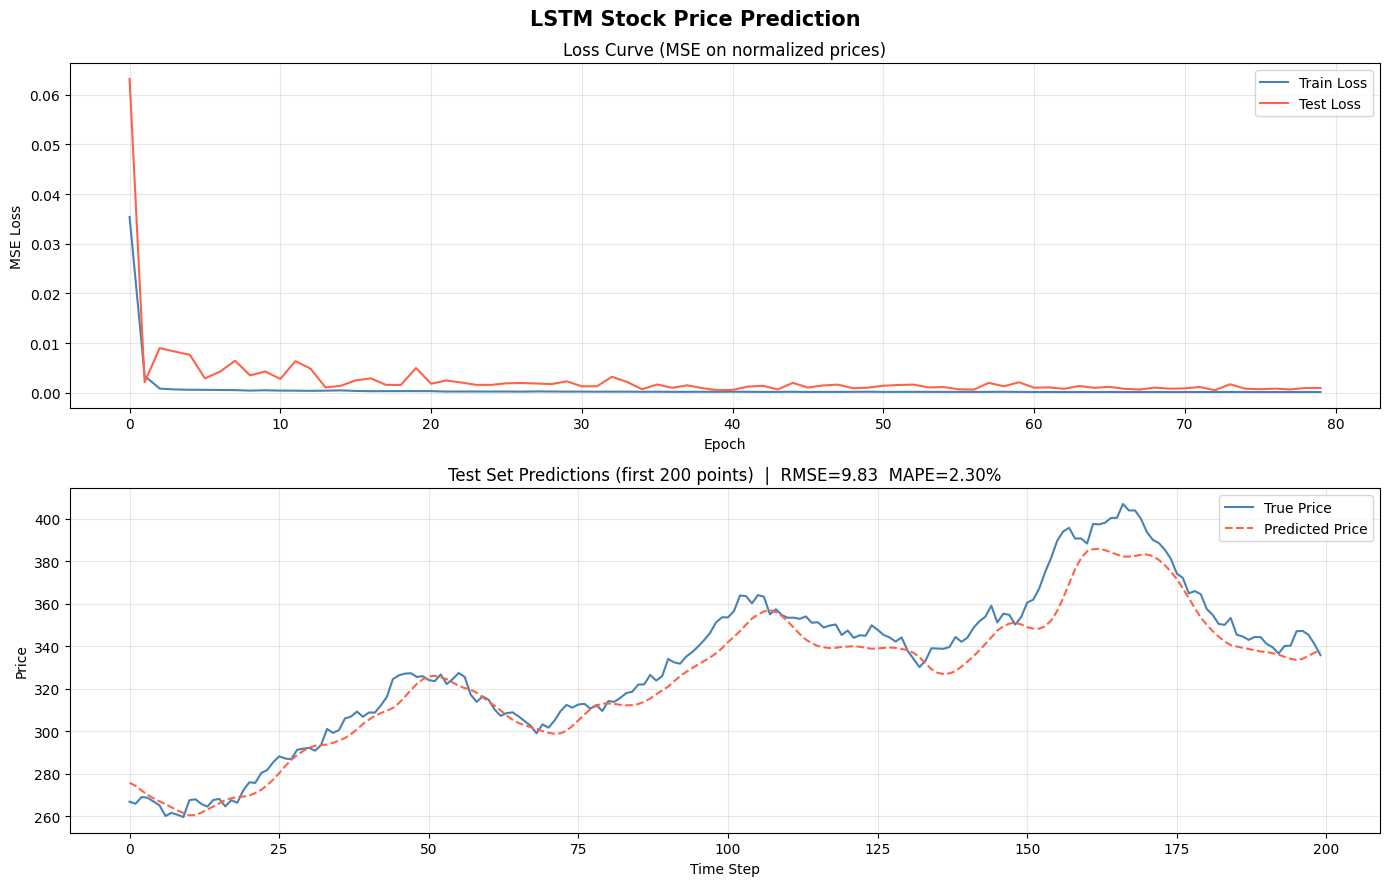

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("LSTM Stock Price Prediction", fontsize=15, fontweight='bold')

# 上图：损失曲线
ax1 = axes[0]
ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.plot(test_losses,  label='Test Loss',  color='tomato')
ax1.set_title("Loss Curve (MSE on normalized prices)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# 下图：预测 vs 真实（取测试集前 200 个点）
ax2 = axes[1]
show = min(200, len(all_true))
ax2.plot(all_true[:show],  label='True Price',      color='steelblue', linewidth=1.5)
ax2.plot(all_preds[:show], label='Predicted Price', color='tomato',    linewidth=1.5, linestyle='--')
ax2.set_title(f"Test Set Predictions (first {show} points)  |  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Price")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs("dist", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "price_min": price_min,
    "price_max": price_max,
    "seq_len":   SEQ_LEN,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
}, "dist/lstm_stock.pth")
print("Model saved to dist/lstm_stock.pth")

Model saved to dist/lstm_stock.pth
